In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "ticks", context =  "talk", palette = "husl")

In [33]:
import cv2

In [34]:
from tqdm import tqdm

In [35]:
import re
import nltk
# nltk.download('stopwords')
from nltk.corpus import stopwords

In [36]:
from wordcloud import WordCloud

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
from sklearn.svm import SVC

In [42]:
from sklearn.svm import LinearSVC

In [43]:
from sklearn.neighbors import KNeighborsClassifier

In [44]:
from sklearn.ensemble import GradientBoostingClassifier

In [45]:
from imblearn.metrics import classification_report_imbalanced, geometric_mean_score
from sklearn.metrics import f1_score

In [46]:
import time

In [47]:
X_tr = pd.read_csv("../../../002_Dataset_ALL/X_train_update.csv", index_col=0)
y_tr = pd.read_csv("../../../002_Dataset_ALL/Y_train_CVw08PX.csv", index_col=0)
# X_ts = pd.read_csv("../../../002_Dataset_ALL/X_test_update.csv", index_col=0)

In [48]:
X_tr

,designation,description,productid,imageid
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786
...,...,...,...,...
84911,The Sims [ Import Anglais ],NaN,206719094,941495734
84912,Kit piscine acier NEVADA déco pierre Ø 3.50m x...,<b>Description complète :</b><br />Kit piscine...,3065095706,1188462883
84913,Journal Officiel De La Republique Francaise N°...,NaN,440707564,1009325617
84914,Table Basse Bois De Récupération Massif Base B...,<p>Cette table basse a un design unique et con...,3942400296,1267353403


In [49]:
# Nombre de NaN par variable
X_tr.isna().sum()
# remarque: il n'y a que la variable 'description' qui 29800 NaN. Les autres variables n'ont pas de NaN

designation        0
description    29800
productid          0
imageid            0
dtype: int64

In [50]:
X_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   designation  84916 non-null  object
 1   description  55116 non-null  object
 2   productid    84916 non-null  int64 
 3   imageid      84916 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 3.2+ MB


In [51]:
print(X_tr.shape, y_tr.shape)

(84916, 4) (84916, 1)


In [52]:
# Analyse de la variable cibe y_train
y_tr

,prdtypecode
0,10
1,2280
2,50
3,1280
4,2705
...,...
84911,40
84912,2583
84913,2280
84914,1560


In [53]:
y_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prdtypecode  84916 non-null  int64
dtypes: int64(1)
memory usage: 1.3 MB


In [54]:
# vérifier les catégories de y_train
print("le nombre total des classes de prdtypecode: \n", y_tr['prdtypecode'].nunique())
print("les classes de prdtypecode : \n", y_tr.value_counts())

le nombre total des classes de prdtypecode: 
 27
les classes de prdtypecode : 
 prdtypecode
2583           10209
1560            5073
1300            5045
2060            4993
2522            4989
1280            4870
2403            4774
2280            4760
1920            4303
1160            3953
1320            3241
10              3116
2705            2761
1140            2671
2582            2589
40              2508
2585            2496
1302            2491
1281            2070
50              1681
2462            1421
2905             872
60               832
2220             824
1301             807
1940             803
1180             764
Name: count, dtype: int64


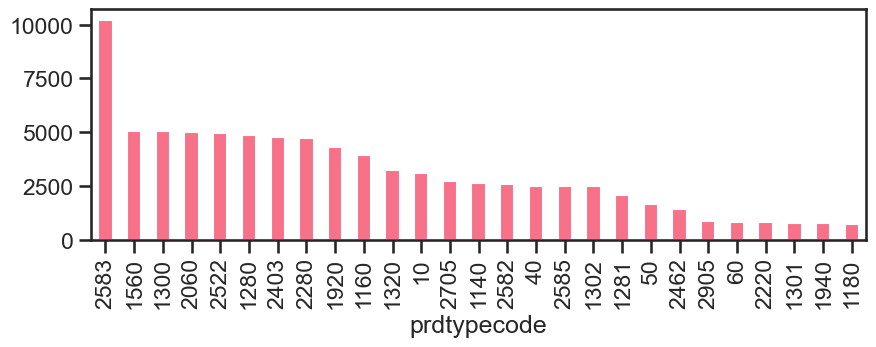

In [55]:
# Vérifier la distribution des prdtypecode :
y_tr['prdtypecode'].value_counts().plot(kind='bar', figsize=(10,3));

In [56]:
# fusion de X_tr et y_tr
fusion = y_tr.merge(X_tr, left_index=True, right_index=True)
display(X_tr.head(2))
display(X_tr.tail(2))
display(y_tr.head(2))
display(y_tr.tail(2))
display(fusion)

,designation,description,productid,imageid
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237


,designation,description,productid,imageid
84914,Table Basse Bois De Récupération Massif Base B...,<p>Cette table basse a un design unique et con...,3942400296,1267353403
84915,Gomme De Collection 2 Gommes Pinguin Glace Ver...,NaN,57203227,684671297


,prdtypecode
0,10
1,2280


,prdtypecode
84914,1560
84915,2522


,prdtypecode,designation,description,productid,imageid
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,50,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,1280,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,2705,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786
...,...,...,...,...,...
84911,40,The Sims [ Import Anglais ],NaN,206719094,941495734
84912,2583,Kit piscine acier NEVADA déco pierre Ø 3.50m x...,<b>Description complète :</b><br />Kit piscine...,3065095706,1188462883
84913,2280,Journal Officiel De La Republique Francaise N°...,NaN,440707564,1009325617
84914,1560,Table Basse Bois De Récupération Massif Base B...,<p>Cette table basse a un design unique et con...,3942400296,1267353403


In [57]:
# afficher les lignes concernant le prdtypecode le plus fréquent (2583)
fusion.loc[fusion['prdtypecode'] == 2583]
# remarque: ces produits semblent liés à la 'piscine'

,prdtypecode,designation,description,productid,imageid
20,2583,Kit de désinfection pour piscines enfants 20990,NaN,3936362802,1268740880
39,2583,Bouée gonflable River tube - OOGARDEN,Bouée gonflable River tube en PVC idéale pour ...,3147314797,1225887302
53,2583,Testeur électronique de pH,Utilisation du Testeur électronique de pHGrâce...,207151480,941622055
58,2583,Pompe de filtration Speck Badu 95,NaN,4128438373,1295960377
64,2583,AstralCom 1 CV Mono de DAB - Surpresseur piscine,Tension (V) : Monophasé - 230 V Puissance : 1...,1857269337,1105831362
...,...,...,...,...,...
84874,2583,Skimmer standard petite meurtrière - Vis PARKE...,Type de pièces : Skimmer Revêtement : Liner ...,2151623756,1128623127
84887,2583,Linxor - Bâche à Bulles 300 microns piscine 2m...,NaN,1951685693,1317940307
84905,2583,Bâche été pour piscine Lili Ø 255 m,<p>La <strong>bâche été</strong> permet d&#39;...,1886035156,1109239046
84909,2583,espa - kit complet de nage à contre courant 39...,espa espa - kit complet de nage à contre coura...,853455937,1043841028


In [58]:
# afficher quelques valeurs de la variable designation
print(fusion['designation'].loc[0])
print(fusion['designation'].loc[84913])

Olivia: Personalisiertes Notizbuch / 150 Seiten / Punktraster / Ca Din A5 / Rosen-Design
Journal Officiel De La Republique Francaise N° 46 Du 15/02/1871 - Changement D'adresses - Partie Officielle - Partie Non Officielle - Elections A L'assemblee Nationale - Ravitaillement De Paris - Nouvelles Etrangeres  -  Italie  -  Amerique.


In [59]:
# afficher quelques valeurs de la variable designation, pour le prdtypecode le plus fréquent (2583) - sujet piscine
print(fusion['designation'].loc[20])
print(fusion['designation'].loc[84912])

Kit de désinfection pour piscines enfants 20990
Kit piscine acier NEVADA déco pierre Ø 3.50m x 0.90m


In [28]:
fusion.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   prdtypecode  84916 non-null  int64 
 1   designation  84916 non-null  object
 2   description  55116 non-null  object
 3   productid    84916 non-null  int64 
 4   imageid      84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 5.9+ MB


In [60]:
essai4 = fusion.copy()
print(essai4.info())
display(essai4.head(3))

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   prdtypecode  84916 non-null  int64 
 1   designation  84916 non-null  object
 2   description  55116 non-null  object
 3   productid    84916 non-null  int64 
 4   imageid      84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 5.9+ MB
None


,prdtypecode,designation,description,productid,imageid
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,50,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978


In [61]:
# Chemin de base vers les images
image_dir = "../../../002_Dataset_ALL/images/image_train"

# Création directe des noms de fichiers avec opérations vectorisées
filenames = (
    "image_" 
    + essai4["imageid"].astype(str) 
    + "_product_" 
    + essai4["productid"].astype(str) 
    + ".jpg"
)

# Construction des chemins complets
filepaths = image_dir + "/" + filenames

# Création directe du DataFrame
essai4["filepath"] = filepaths

display(essai4.head(6))

# Afficher les valeurs de la colonne 3 (filepath) pour les index 0 à 3
print(essai4.iloc[0, 5])
print(essai4.iloc[3, 5])

,prdtypecode,designation,description,productid,imageid,filepath
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,../../../002_Dataset_ALL/images/image_train/im...
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,../../../002_Dataset_ALL/images/image_train/im...
2,50,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,../../../002_Dataset_ALL/images/image_train/im...
3,1280,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496,../../../002_Dataset_ALL/images/image_train/im...
4,2705,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,../../../002_Dataset_ALL/images/image_train/im...
5,2280,Afrique Contemporaine N° 212 Hiver 2004 - Doss...,NaN,5862738,393356830,../../../002_Dataset_ALL/images/image_train/im...


../../../002_Dataset_ALL/images/image_train/image_1263597046_product_3804725264.jpg
../../../002_Dataset_ALL/images/image_train/image_457047496_product_50418756.jpg


In [62]:
fusion.head(2)

,prdtypecode,designation,description,productid,imageid
0,10,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,2280,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237


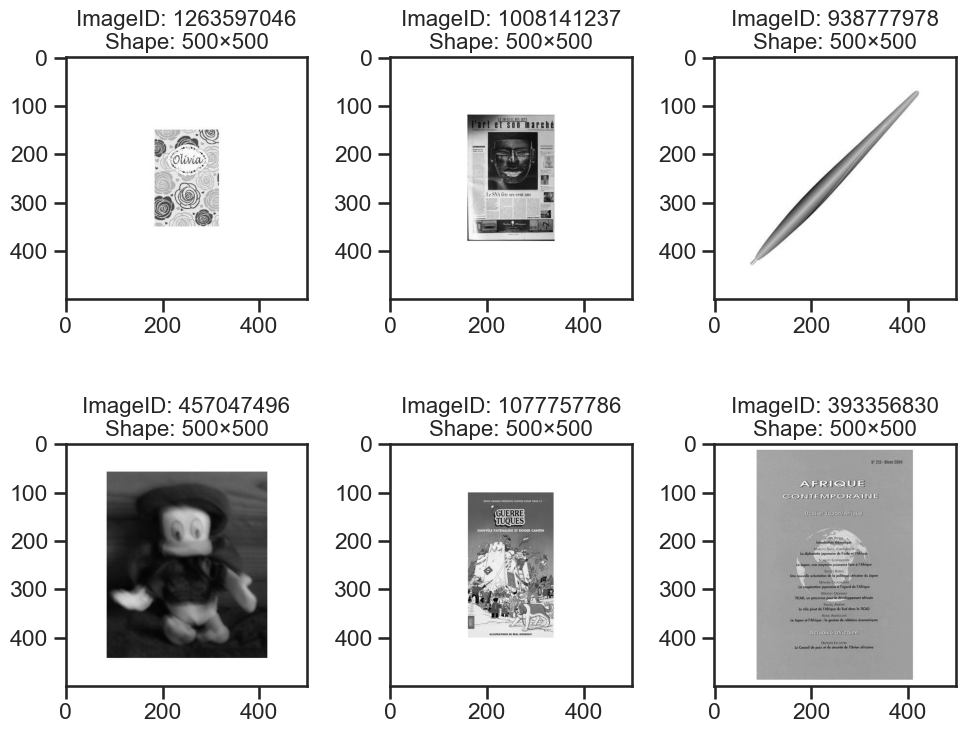

In [63]:
# Pour afficher les images à partir d'une liste de imgeid
# Liste des imageid à afficher (ici 6 images pour 2lignes x 3colonnes)
image_ids_to_show = [1263597046, 1008141237, 938777978, 457047496, 1077757786, 393356830]

# Création de la figure avec 2 lignes et 3 colonnes
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()  # Pour itérer facilement

for i, imageid in enumerate(image_ids_to_show):
    # Récupérer le chemin
    filepath = essai4.loc[essai4["imageid"] == imageid, "filepath"].values[0]

    # Lire l'image en niveaux de gris
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        axes[i].imshow(img, cmap='gray')
        h, w = img.shape  # Récupère la shape (hauteur, largeur)
        axes[i].set_title(f"ImageID: {imageid}\nShape: {h}×{w}", fontsize=16)
        # axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'Introuvable', ha='center', va='center')
        # axes[i].axis('off')

plt.tight_layout()
plt.show()

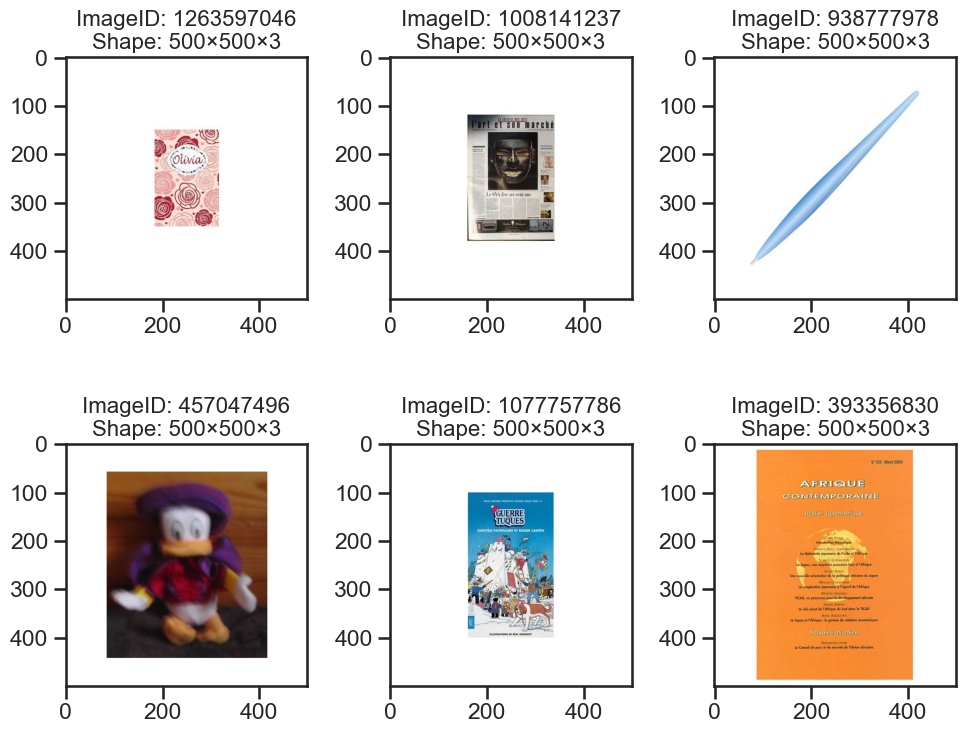

In [64]:
# Pour afficher les images à partir d'une liste de imageid
# Liste des imageid à afficher (ici 6 images pour 2 lignes x 3 colonnes)
image_ids_to_show = [1263597046, 1008141237, 938777978, 457047496, 1077757786, 393356830]

# Création de la figure avec 2 lignes et 3 colonnes
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()  # Pour itérer facilement

for i, imageid in enumerate(image_ids_to_show):
    # Récupérer le chemin
    filepath = essai4.loc[essai4["imageid"] == imageid, "filepath"].values[0]

    # Lire l'image en couleur
    img = cv2.imread(filepath, cv2.IMREAD_COLOR)
    
    # Vérifier que l'image a bien été lue
    if img is not None:
        # Convertir BGR -> RGB pour matplotlib
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img)
        h, w, c = img.shape  # Récupère la shape (hauteur, largeur, canaux)
        axes[i].set_title(f"ImageID: {imageid}\nShape: {h}×{w}×{c}", fontsize=16)
        # axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'Introuvable', ha='center', va='center')
        # axes[i].axis('off')

plt.tight_layout()
plt.show()


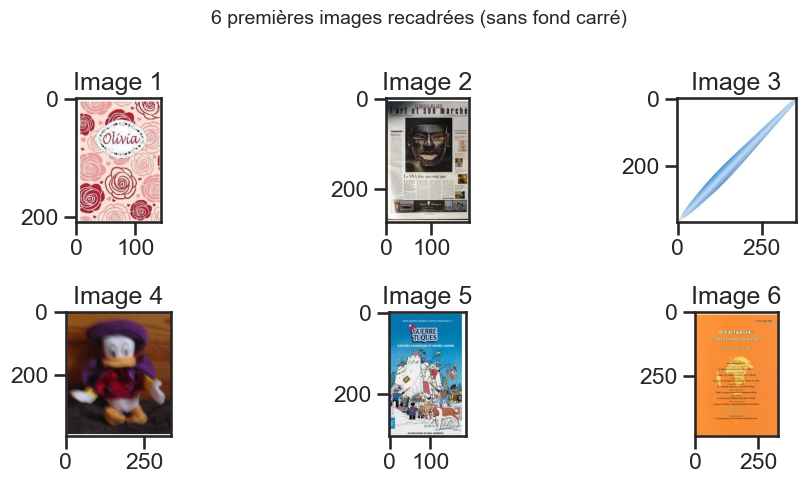

In [70]:
# -------------------------------
# TEST 1 : Lecture image en couleur et recadrage
# -------------------------------
def color_crop_image(filepath):
    """
    Lecture d'une image en couleur,
    suppression des bordures blanches uniquement
    (sans redimensionnement ni mise au carré).
    """
    # Lecture en couleur
    img = cv2.imread(filepath, cv2.IMREAD_COLOR)
    
    if img is None:
        # Si le chemin est invalide, renvoyer None
        return None

    # Conversion BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Conversion en niveaux de gris pour détecter les bords blancs
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Création d’un masque binaire : les pixels non blancs deviennent 255
    _, thresh = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY_INV)

    # Trouver les coordonnées des pixels non blancs
    coords = cv2.findNonZero(thresh)

    if coords is not None:
        # Calcul du rectangle englobant les pixels non blancs
        x, y, w, h = cv2.boundingRect(coords)
        img = img[y:y+h, x:x+w]

    return img


# -------------------------------
# Transformation et affichage des 6 premières images
# -------------------------------
# Sélection des 6 premières images du DataFrame
ex1 = essai4["filepath"].head(6).tolist()

# Application de la fonction
img_color_crop = [color_crop_image(p) for p in ex1]

# Affichage
plt.figure(figsize=(10, 5))
for i, img in enumerate(img_color_crop):
    plt.subplot(2, 3, i + 1)
    if img is not None:
        plt.imshow(img)
        # plt.axis('off')
        plt.title(f"Image {i+1}")
    else:
        plt.text(0.5, 0.5, "Image non trouvée", ha='center', va='center')
plt.suptitle("6 premières images recadrées (sans fond carré)", fontsize=14)
plt.tight_layout()
plt.show()


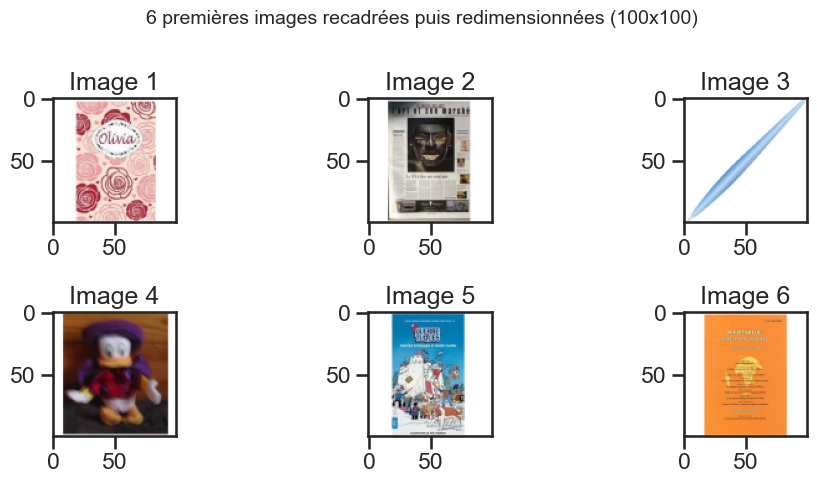

In [74]:
# -------------------------------
# TEST 2 : Met une image sur un fond blanc carré, puis la redimensionne à final_size
# -------------------------------

def square_and_resize(img, final_size=(100, 100)):
    """
    Met une image sur un fond blanc carré, puis la redimensionne à final_size.
    """
    if img is None:
        # Si image vide, renvoie une image blanche
        return np.full((final_size[1], final_size[0], 3), 255, dtype=np.uint8)

    h, w = img.shape[:2]
    size = max(h, w)

    # Création d'une image blanche carrée
    square = np.full((size, size, 3), 255, dtype=np.uint8)

    # Calcul des offsets pour centrer l’image
    y_offset = (size - h) // 2
    x_offset = (size - w) // 2
    square[y_offset:y_offset+h, x_offset:x_offset+w] = img

    # Redimensionnement final à 100x100
    square = cv2.resize(square, final_size, interpolation=cv2.INTER_AREA)

    return square


# -------------------------------
# Application : recadrage + fond carré
# -------------------------------
img_final = []
for p in ex1:
    img_cropped = color_crop_image(p)           # Étape 1 : recadrage
    img_square = square_and_resize(img_cropped)  # Étape 2 : fond carré + resize
    img_final.append(img_square)


# -------------------------------
# Affichage du résultat final
# -------------------------------
plt.figure(figsize=(10, 5))
for i, img in enumerate(img_final):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    # plt.axis('off')
    plt.title(f"Image {i+1}")
plt.suptitle("6 premières images recadrées puis redimensionnées (100x100)", fontsize=14)
plt.tight_layout()
plt.show()


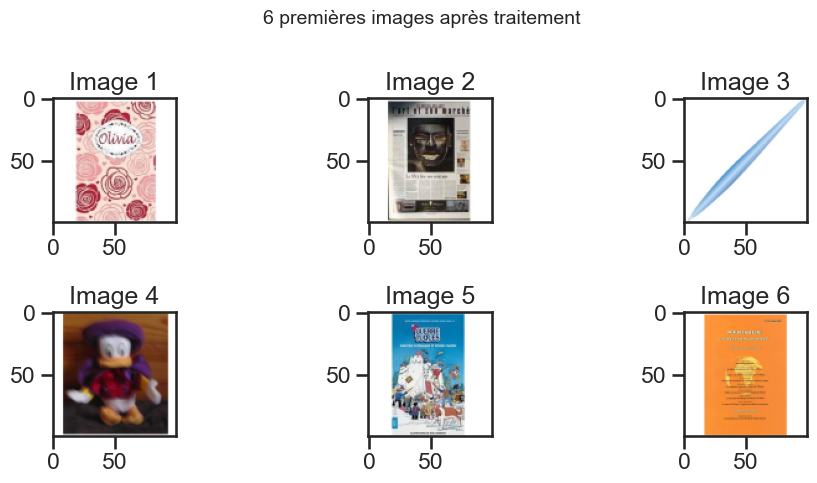

In [76]:
# -------------------------------
# TEST 3: Lecture image en couleur + recadrage + format 100x100 fond blanc
# -------------------------------
def color_crop_square_resize(filepath, final_size=(100, 100)):
    """
    Lecture d'une image en couleur,
    suppression des bordures blanches,
    mise au carré avec fond blanc si nécessaire,
    puis redimensionnement à la taille finale (100x100).
    """
    # Lecture en couleur
    img = cv2.imread(filepath, cv2.IMREAD_COLOR)
    
    if img is None:
        # Si le chemin est invalide, renvoyer une image blanche
        return np.full((final_size[1], final_size[0], 3), 255, dtype=np.uint8)
    
    # Conversion BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Conversion en niveau de gris pour détecter les zones non blanches
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Création d’un masque binaire (tout ce qui est proche du blanc devient 0)
    _, thresh = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY_INV)

    # Trouve les coordonnées non blanches
    coords = cv2.findNonZero(thresh)

    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        img = img[y:y+h, x:x+w]

    # Mise au carré (fond blanc si nécessaire)
    h, w = img.shape[:2]
    if h != w:
        size = max(h, w)
        square = np.full((size, size, 3), 255, dtype=np.uint8)
        y_offset = (size - h) // 2
        x_offset = (size - w) // 2
        square[y_offset:y_offset+h, x_offset:x_offset+w] = img
        img = square

    # Redimensionnement à la taille finale
    img = cv2.resize(img, final_size, interpolation=cv2.INTER_AREA)

    return img


# -------------------------------
# Transformation et affichage des 6 premières images
# -------------------------------
# Sélection des 6 premières images du DataFrame
ex1 = essai4["filepath"].head(6).tolist()

# Application de la fonction
img_color_crop = [color_crop_square_resize(p) for p in ex1]

# Affichage
plt.figure(figsize=(10, 5))
for i, img in enumerate(img_color_crop):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    # plt.axis('off')
    plt.title(f"Image {i+1}")
plt.suptitle("6 premières images après traitement", fontsize=14)
plt.tight_layout()
plt.show()


In [77]:
# -------------------------------
# ETAPE 1: Prétraitement et chargement des images
# -------------------------------
# 1.1 - REFAIRE la Fontion pour Prétraitement et chargement des images
def preprocess_image(path, final_size=(100, 100)):
    """
    Lecture d'une image en niveaux de gris,
    suppression des bordures blanches,
    mise au carré avec fond blanc si nécessaire,
    puis redimensionnement à la taille finale (100x100).
    """
    # Lecture en niveaux de gris
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        # Si le chemin est invalide, renvoyer une image blanche
        return np.full(final_size, 255, dtype=np.uint8)
    
    # Seuil pour détecter les pixels non blancs
    _, thresh = cv2.threshold(img, 250, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(cv2.bitwise_not(thresh))

    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        img = img[y:y+h, x:x+w]

    # Rendre carré en ajoutant des pixels blancs
    h, w = img.shape
    if h > w:
        pad = (h - w) // 2
        img = cv2.copyMakeBorder(img, 0, 0, pad, h - w - pad, cv2.BORDER_CONSTANT, value=255)
    elif w > h:
        pad = (w - h) // 2
        img = cv2.copyMakeBorder(img, pad, w - h - pad, 0, 0, cv2.BORDER_CONSTANT, value=255)

    # Redimensionnement à la taille finale
    img = cv2.resize(img, final_size, interpolation=cv2.INTER_AREA)
    return img

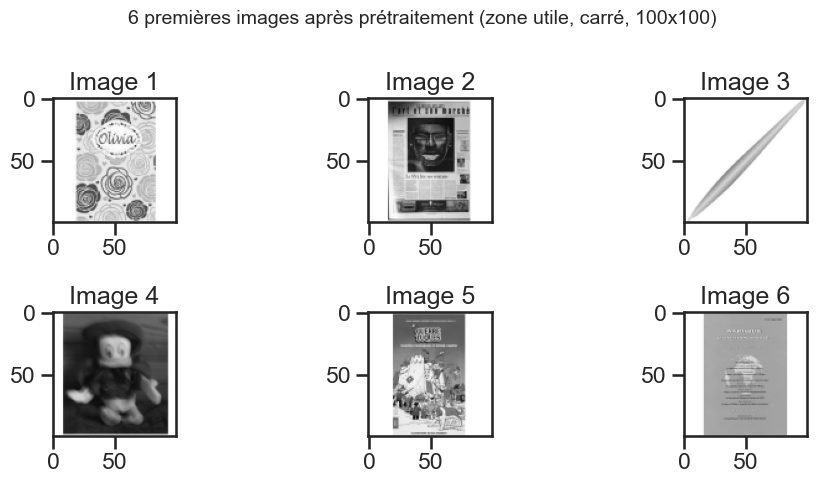

In [78]:
# -------------------------------
# ETAPE 1: Prétraitement et chargement des images
# -------------------------------
# 1.2 - Transformation et affichage des 6 premières images
# Sélectionne les 6 premières images du dataframe
sample_paths = essai4["filepath"].head(6).tolist()

# Transformation
processed_images = [preprocess_image(p) for p in sample_paths]

# Affichage
plt.figure(figsize=(10, 5))
for i, img in enumerate(processed_images):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    # plt.axis('off')
    plt.title(f"Image {i+1}")
plt.suptitle("6 premières images après prétraitement (zone utile, carré, 100x100)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------
# ETAPE 1: Prétraitement et chargement des images
# -------------------------------
# NE PAS REFAIRE de 1.3 (application à toutes les images) à 1.6 (sauvegarder le tableau des images prétraité=100x100 gris)

In [34]:
# -------------------------------
# ETAPE 1: Prétraitement et chargement des images
# -------------------------------
# 1.3 Application à toutes les images du dataframe

X_img = []
for path in tqdm(essai4["filepath"], desc="Chargement des images"):
    img = preprocess_image(path)
    X_img.append(img)

Chargement des images: 100%|██████████| 84916/84916 [12:54<00:00, 109.67it/s]


In [35]:
# -------------------------------
# ETAPE 1: Prétraitement et chargement des images
# -------------------------------
# 1.4 - Convertit la liste Python X_images en un tableau NumPy, pour faciliter la manipulation et l’entrée dans les modèles ML.
X_img = np.array(X_img)

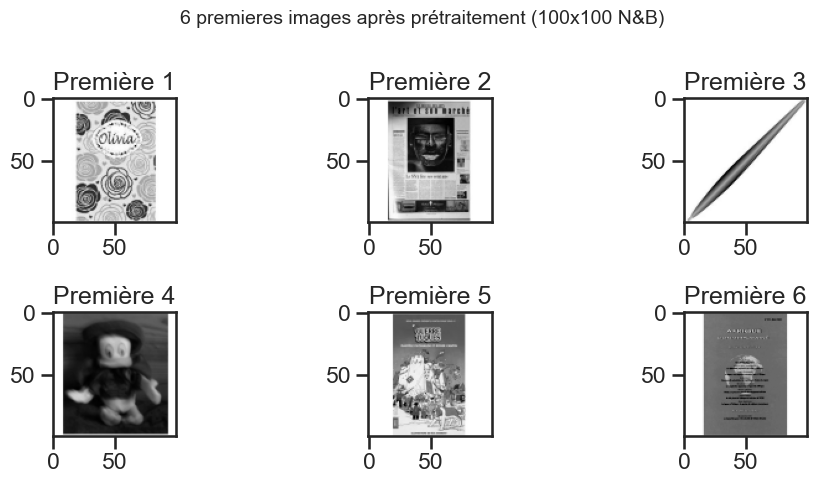

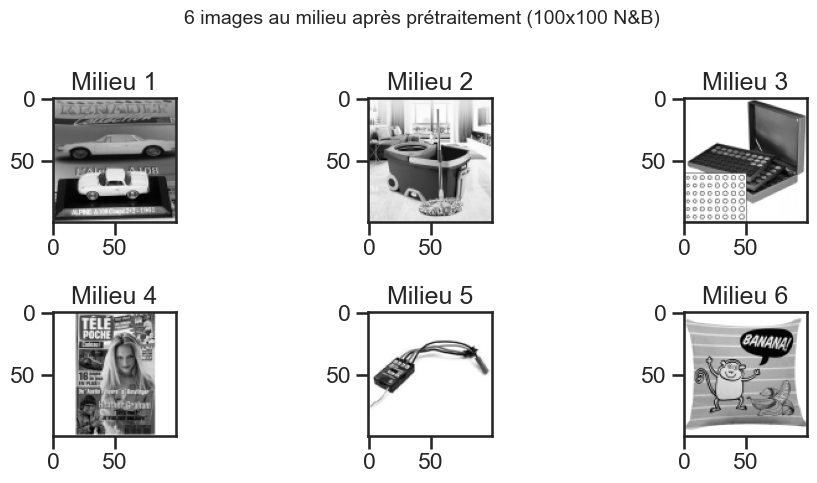

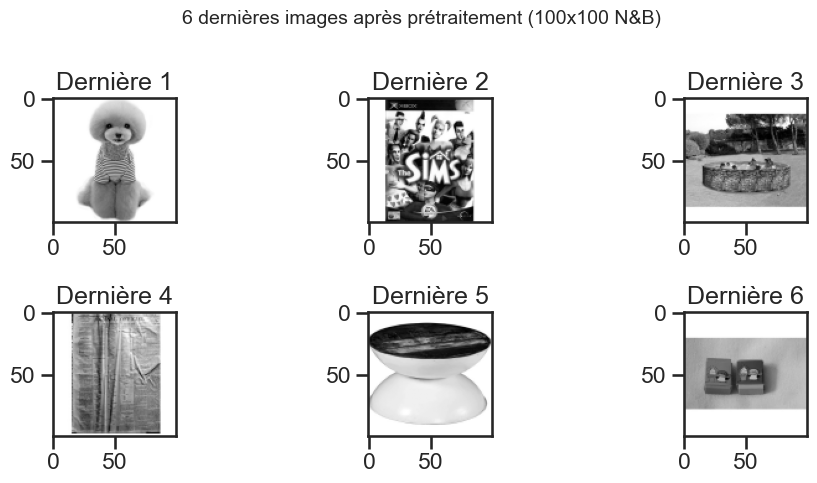

In [101]:
# -------------------------------
# ETAPE 1: Prétraitement et chargement des images
# -------------------------------
# 1.5 - VERIFIER les images traitées 

# Vérifie qu'il y a bien au moins 6 images
n = 6 if len(X_img) >= 6 else len(X_img)

# Affiche les 6 premières images après traitement
plt.figure(figsize=(10, 5))
for i in range(n):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_img[i], cmap='gray')  # <-- ici on prend les 6 premieres
    # plt.axis('off')
    plt.title(f"Première {i+1}")
plt.suptitle("6 premieres images après prétraitement (100x100 N&B)", fontsize=14)
plt.tight_layout()
plt.show()

# Affiche les 6 dernières images après traitement
plt.figure(figsize=(10, 5))
for i in range(n):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_img[-n-8000 + i], cmap='gray')  # <-- ici on prend les 6 img de -8006 à -8000
    # plt.axis('off')
    plt.title(f"Milieu {i+1}")
plt.suptitle("6 images au milieu après prétraitement (100x100 N&B)", fontsize=14)
plt.tight_layout()
plt.show()

# Affiche les 6 dernières images après traitement
plt.figure(figsize=(10, 5))
for i in range(n):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_img[-n + i], cmap='gray')  # <-- ici on prend les 6 dernières
    # plt.axis('off')
    plt.title(f"Dernière {i+1}")
plt.suptitle("6 dernières images après prétraitement (100x100 N&B)", fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
# -------------------------------
# ETAPE 1: Prétraitement et chargement des images
# -------------------------------
# 1.6 - SAUVEGARDER le tableau prétraité en format .npy
# -------------------------------
np.save("X_img_100x100px_gris.npy", X_img)


In [39]:
# -------------------------------
# ETAPE 1: Prétraitement et chargement des images
# -------------------------------
# A CONTINUER à partir de 1.7

In [79]:
# -------------------------------
# ETAPE 1: Prétraitement et chargement des images
# -------------------------------
# 1.7 - CHARGER le tableau prétraité en format .npy
# -------------------------------
X_img = np.load("X_img_100x100px_gris.npy")

In [83]:
# -------------------------------
# ETAPE 1: Prétraitement et chargement des images
# -------------------------------
# 1.8 - Mise à plat des images (100x100 -> 10 000 pixels par image)
# -------------------------------
# 1.8.1 - Vérifier la shape des 6 premières images AVANT le reshape
for i in range(6):
    print(f"Image {i+1} : shape = {X_img[i].shape}")

# Vérifier la shape de X_img
print("shape de X_img", X_img.shape)

Image 1 : shape = (100, 100)
Image 2 : shape = (100, 100)
Image 3 : shape = (100, 100)
Image 4 : shape = (100, 100)
Image 5 : shape = (100, 100)
Image 6 : shape = (100, 100)
shape de X_img (84916, 100, 100)


In [84]:
# -------------------------------
# ETAPE 1: Prétraitement et chargement des images
# -------------------------------
# 1.8 - Mise à plat des images (100x100 -> 10 000 pixels par image)
# -------------------------------
# 1.8.2 - APLATIR = Faire le reshapre
X_images = X_img.reshape(len(X_img), -1)  #len(X_img) = nb d'images; -1: Laisse NumPy calculer automatiquement le nombre total de colonnes

# Vérifier la shape de X_img
print("shape de X_images", X_images.shape)

# Vérifier la shape des 6 premiers vecteurs
for i in range(6):
    print(f"Image {i+1} : shape = {X_images[i].shape}")

shape de X_images (84916, 10000)
Image 1 : shape = (10000,)
Image 2 : shape = (10000,)
Image 3 : shape = (10000,)
Image 4 : shape = (10000,)
Image 5 : shape = (10000,)
Image 6 : shape = (10000,)


In [85]:
# -------------------------------
# ETAPE 1: Prétraitement et chargement des images
# -------------------------------
# 1.8 - Mise à plat des images (100x100 -> 10 000 pixels par image)
# -------------------------------
# 1.8.2 - suite
# Explication shape

# shape de X_images (84916, 10000) => 84916 échantillons/ images/ lignes, chaque image avec 10000 colonnes /feature / valeurs de pixel
# 1 seule Image : shape = (10000,) => 1 échantillon/image, avec 10000 valeurs de pixel (features)

# ATTENTION: shape (10000, 1) =>  10 000 échantillons/lignes, avec 1 seule colonne/ feature => NON => Pas adapté pour un image pour X_train, X_test

In [86]:
# -------------------------------
# ETAPE 1: Prétraitement et chargement des images
# -------------------------------
# 1.8 - Mise à plat des images (100x100 -> 10 000 pixels par image)
# -------------------------------
# 1.8.3 - Vérifier les valeurs min et max (valeur de niveaux de gris, de 0 à 255) des 6 premiers vecteurs (après reshape)
for i in range(6):
    img = X_images[i]
    print(f"Image {i+1} : min = {img.min()}, max = {img.max()}")

# vérification globale sur tout le jeu d’images
print("\nValeurs globales :")
print(f"Min global = {X_images.min()}")
print(f"Max global = {X_images.max()}")

Image 1 : min = 39, max = 255
Image 2 : min = 14, max = 255
Image 3 : min = 137, max = 255
Image 4 : min = 12, max = 255
Image 5 : min = 7, max = 255
Image 6 : min = 99, max = 255

Valeurs globales :
Min global = 0
Max global = 255


In [87]:
# -------------------------------
# ETAPE 2: Séparation X_images et y
# -------------------------------

# Pour variable explicative X_images:
# on a déjà fait avec les lignes de codes de §1.8.2 ci-dessus (X_images = X_img.reshape(len(X_img), -1))

# Cible
y = essai4["prdtypecode"].values


In [88]:
# -------------------------------
# ETAPE 3: Division train/test
# -------------------------------
# 80% train, 20% test, stratification (stratify=y) pour garder la proportion des classes
X_train_img, X_test_img, y_train, y_test = train_test_split(X_images, y, test_size=0.2, 
                                                            stratify=y,  # pour garder la proportion des classes
                                                            random_state=42)

print("Taille du train :", X_train_img.shape)
print("Taille du test :", X_test_img.shape)

Taille du train : (67932, 10000)
Taille du test : (16984, 10000)


In [89]:
# -------------------------------
# ETAPE 4: Normalisation des pixels
# -------------------------------
# Convertir les valeurs pixels 0-255 en 0-1 pour certains modèles ML
# Pour les modèles basés sur des distances = sensibles à l’échelle des variables (Ex: k-NN, SVM (RBF), LogisticRegression)
# Pour les modèles linéaires (LogisticRegression, LinearSVC): Avec des valeurs entre 0 et 1, le modèle apprend plus vite et plus précisément
# Pour les modèles d’arbres (RandomForest, XGBoost, DecisionTree):insensibles à l’échelle des variables, 
# Ils ne nécessitent pas forcément de normalisation, car ils se basent sur des comparaisons (seuils).
X_train_img = X_train_img / 255.0
X_test_img = X_test_img / 255.0

In [90]:
# -------------------------------
# ETAPE 4: Normalisation des pixels
# -------------------------------
# Résumé pour la nécessité de la normalisation en fonction des modèle:
# SVM / Logistic Regression / k-NN => Oui => Car Meilleure convergence, stabilité numérique
# Random Forest / Decision Tree => Pas obligatoire => Car Insensible à l’échelle
# CNN / Deep Learning => Oui => Car Bonnes pratiques, stabilité de l’entraînement
# Conlusion: comparer plusieurs modèles (arbres, SVM, régression logistique…),
# il vaut mieux garder les données normalisées pour tous pour plus cohérence.

In [103]:
# -------------------------------
# ETAPE 5: Modelisation
# -------------------------------
# "Logistic Regression": LogisticRegression(),
# "SVM (RBF)": SVC(kernel='rbf', gamma='scale'),
# "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
# "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5)
# -------------------------------


In [97]:
# -------------------------------
# ETAPE 4: Modelisation
# -------------------------------
# 4.1 - Logistic Regression
# -------------------------------

# La durée de l'entrainement + prediction
start = time.time()

# Logistic Regression
lr = LogisticRegression()  
lr.fit(X_train_img, y_train)
y_pred_lr = lr.predict(X_test_img)

end = time.time()
print("Durée Logistic Regression (min) =", (end-start)/60)

C:\Users\Duong\anaconda3\envs\Rakuten_Duong_20251017\Lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Durée Logistic Regression (min) = 2.334032618999481


In [98]:
# message ci-dessus = cela veut dire que :
# le modèle a fait tous les itérations (100 par défaut), mais n’a pas encore trouvé un minimum stable pour la fonction de coût.
# Donc peut être le nb d'itérations (ici = 100) est trop faible
# Or avant , on a fait 1000 itérations avec le temps de calcul d' 1h et on n'a pas non plus trouvé un minimum stable pour la fonction de coût
# Donc on laisse tel quel pour ce premier calcul de Logistic Regression

In [102]:
# -------------------------------
# ETAPE 4: Modelisation
# -------------------------------
# 4.1 - Logistic Regression
print("F1-score Logistic Regression:", f1_score(y_test, y_pred_lr, average='weighted'))
print("Rapport Classification Logistic Regression  :")
print(classification_report_imbalanced(y_test,y_pred_lr))
print("Matrice de confusion Logistic Regression:")
display(pd.crosstab(y_test, y_pred_lr, rownames=['Reel'], colnames=['Predit']))
      

F1-score Logistic Regression: 0.23506481026543638
Rapport Classification Logistic Regression  :
                   pre       rec       spe        f1       geo       iba       sup

         10       0.31      0.24      0.98      0.27      0.49      0.22       623
         40       0.29      0.19      0.99      0.23      0.43      0.17       502
         50       0.20      0.06      1.00      0.09      0.24      0.05       336
         60       0.08      0.02      1.00      0.03      0.13      0.02       166
       1140       0.18      0.13      0.98      0.15      0.35      0.11       534
       1160       0.54      0.56      0.98      0.55      0.74      0.53       791
       1180       0.00      0.00      1.00      0.00      0.00      0.00       153
       1280       0.07      0.03      0.98      0.04      0.17      0.03       974
       1281       0.04      0.00      1.00      0.00      0.05      0.00       414
       1300       0.15      0.10      0.97      0.12      0.31      0.09 

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,152,23,1,0,5,45,0,19,0,3,...,0,119,60,3,61,0,52,3,54,2
40,14,93,3,2,9,32,0,15,1,9,...,0,67,44,2,10,1,121,1,28,8
50,5,4,19,1,14,6,0,11,1,21,...,0,15,21,3,12,2,118,0,11,3
60,2,1,5,3,4,2,0,6,0,10,...,0,5,2,0,5,6,74,1,2,0
1140,24,6,4,0,67,21,0,22,1,19,...,0,41,57,0,24,0,176,0,15,0
1160,23,17,1,0,10,446,0,7,0,4,...,0,122,86,5,6,0,22,0,24,5
1180,7,2,0,0,7,12,0,7,0,7,...,0,24,21,3,2,1,35,0,4,1
1280,15,10,6,0,25,16,0,28,1,64,...,0,33,85,4,78,9,404,3,10,0
1281,10,7,4,1,9,14,0,22,1,14,...,0,28,37,1,20,3,176,1,6,0


In [92]:
# -------------------------------
# ETAPE 4: Modelisation
# -------------------------------
# 4.2 - Random Forest
# -------------------------------
# La durée de l'entrainement + prediction
start = time.time()

# Random Forest (nombre d’arbres réduit pour la vitesse)
rf = RandomForestClassifier(n_estimators=80,  # Réduit le temps. Par défaut, c’est 100 arbres. Pour un test rapide, 80 suffit.
                            max_depth=15,  # éviter des arbres trop profonds = Limite la complexité et le temps de calcul
                            n_jobs=-1,  # Nombre de threads CPU: -1 utilise tous les cœurs disponibles, accélère l’entraînement sur gros jeux.
                            random_state=42)  # Fixe la graine aléatoire, Rend les résultats reproductibles

rf.fit(X_train_img, y_train)
y_pred_rf = rf.predict(X_test_img)

end = time.time()
print("Durée Random Forest (min) =", (end-start)/60)

Durée Random Forest (min) = 2.208564058939616


In [93]:
# -------------------------------
# ETAPE 4: Modelisation
# -------------------------------
# 4.2 - Random Forest
# -------------------------------
print("F1-score Random Forest:", f1_score(y_test, y_pred_rf, average='weighted'))
print("Rapport Classification Random Forest  :")
print(classification_report_imbalanced(y_test,y_pred_rf))
print("Matrice de confusion Random Forest :")
display(pd.crosstab(y_test, y_pred_rf, rownames=['Reel'], colnames=['Predit']))

F1-score Random Forest: 0.3871929391183991
Rapport Classification Random Forest  :
                   pre       rec       spe        f1       geo       iba       sup

         10       0.42      0.41      0.98      0.42      0.64      0.38       623
         40       0.51      0.31      0.99      0.39      0.55      0.29       502
         50       0.75      0.14      1.00      0.24      0.38      0.13       336
         60       0.94      0.09      1.00      0.16      0.30      0.08       166
       1140       0.53      0.18      0.99      0.27      0.43      0.17       534
       1160       0.67      0.68      0.98      0.68      0.82      0.65       791
       1180       0.71      0.03      1.00      0.06      0.18      0.03       153
       1280       0.24      0.07      0.99      0.11      0.27      0.06       974
       1281       0.33      0.02      1.00      0.03      0.13      0.02       414
       1300       0.43      0.46      0.96      0.45      0.67      0.42      1009
   

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,258,13,0,0,4,49,0,7,1,1,...,0,121,77,0,5,0,32,0,41,0
40,16,155,7,0,1,37,0,0,1,22,...,0,54,53,1,3,1,105,0,15,5
50,7,8,48,0,4,4,0,7,0,32,...,0,9,20,8,2,0,146,1,4,0
60,1,6,1,15,0,1,0,2,0,15,...,0,3,7,0,1,0,92,0,0,0
1140,29,6,0,0,98,11,0,18,1,20,...,0,47,94,1,2,0,171,0,17,0
1160,12,4,0,0,2,540,0,2,0,0,...,0,90,101,1,1,0,18,0,6,0
1180,5,3,0,0,6,2,5,4,1,7,...,0,28,37,1,1,0,42,0,4,1
1280,14,5,2,0,15,9,1,70,5,124,...,0,23,124,1,10,1,408,4,12,0
1281,12,7,0,0,5,13,0,20,7,16,...,0,28,57,0,6,0,192,0,6,0


In [94]:
# -------------------------------
# ETAPE 4: Modelisation
# -------------------------------
# 4.3 - KNN
# -------------------------------
# La durée de l'entrainement + prediction
start = time.time()

# KNN (nombre de voisins réduit pour la vitesse)
knn = KNeighborsClassifier(n_neighbors=5,  # nombre de voisins par défaut = 5, pour réduire pour la vitesse
                           n_jobs=-1)  # Nombre de threads CPU: -1 utilise tous les cœurs disponibles, accélère l’entraînement sur gros jeux.

knn.fit(X_train_img, y_train)
y_pred_knn = knn.predict(X_test_img)

end = time.time()
print("Durée KNN (min) =", (end-start)/60)

Durée KNN (min) = 5.866876538594564


In [95]:
# -------------------------------
# ETAPE 4: Modelisation
# -------------------------------
# 4.3 - KNN
# -------------------------------
print("F1-score KNN:", f1_score(y_test, y_pred_knn, average='weighted'))
print("Rapport Classification KNN  :")
print(classification_report_imbalanced(y_test,y_pred_knn))
print("Matrice de confusion KNN :")
display(pd.crosstab(y_test, y_pred_knn, rownames=['Reel'], colnames=['Predit']))

F1-score KNN: 0.3005675636358484
Rapport Classification KNN  :
                   pre       rec       spe        f1       geo       iba       sup

         10       0.19      0.42      0.93      0.27      0.63      0.38       623
         40       0.12      0.06      0.99      0.08      0.25      0.06       502
         50       0.16      0.20      0.98      0.18      0.44      0.18       336
         60       0.26      0.10      1.00      0.14      0.31      0.09       166
       1140       0.17      0.22      0.97      0.19      0.46      0.20       534
       1160       0.65      0.57      0.99      0.61      0.75      0.53       791
       1180       0.09      0.14      0.99      0.11      0.37      0.12       153
       1280       0.15      0.15      0.95      0.15      0.37      0.13       974
       1281       0.06      0.02      0.99      0.03      0.15      0.02       414
       1300       0.39      0.26      0.97      0.32      0.51      0.24      1009
       1301       0.34 

Predit,10,40,50,60,1140,1160,1180,1280,1281,1300,...,2220,2280,2403,2462,2522,2582,2583,2585,2705,2905
Reel,,,,,,,,,,,,,,,,,,,,,
10,264,2,9,0,16,19,4,12,2,6,...,0,51,51,1,103,4,9,1,37,0
40,91,32,15,0,19,14,12,10,3,14,...,0,24,61,1,84,2,34,6,16,0
50,16,6,66,6,11,11,4,19,1,16,...,1,7,12,2,29,7,39,4,5,0
60,7,4,10,16,8,2,2,11,0,4,...,1,2,2,0,14,4,33,5,3,0
1140,62,9,16,1,117,8,5,33,8,8,...,4,15,34,3,66,4,39,5,11,0
1160,96,4,5,0,17,448,3,11,2,3,...,0,33,63,3,78,0,5,0,7,0
1180,16,4,4,1,17,6,21,12,2,3,...,0,2,7,1,16,4,5,0,4,0
1280,34,24,23,3,66,14,17,142,22,54,...,5,15,26,6,99,20,113,8,9,0
1281,36,6,9,0,29,10,9,40,9,10,...,1,10,23,2,59,5,42,3,9,0
